# 01 · Planteamiento del problema con datos
**Torre del Caribe** · Fase 3 · Autor: **Brandon Uriel García Sánchez** · UNRC, LCDN 5° semestre 2026-2

| | |
|---|---|
| **Qué hace** | Delimita el problema y nombra sus variables, actores y relaciones, cada uno con una cifra medida. |
| **Por qué así** | El criterio 1 de la rúbrica pide "identificar variables, actores y relaciones" y una problemática "analizable con datos". Aquí nada se afirma sin su cifra. |
| **Datos de entrada** | Tablas limpias (Silver): SITUR-Q, SECTUR-DataTur, INAH, INEGI DENUE y Censo 2020. |
| **Código** | `backend/torre/radar/planteamiento.py` (este notebook solo llama sus funciones). |
| **Alimenta a** | El Radar (Fase 4): las variables de "presión" y "capacidad" son las candidatas del índice de presión turística. |

## 1. La pregunta y su delimitación
**Pregunta central (Problema Prototípico):** *¿Cómo diseñar una campaña publicitaria basada en Ciencia de Datos que
permita promover estratégicamente un destino turístico del estado seleccionado, atraer segmentos de visitantes de manera
responsable y contribuir a una distribución más equilibrada de los flujos turísticos, aprovechando la capacidad
disponible y reduciendo los impactos económicos, sociales y ambientales asociados con la saturación turística?*

**Delimitación del proyecto:**
- **Dónde:** cinco lugares del sur de Quintana Roo: Chetumal · Bahía Calderitas–Oxtankah · Ruta arqueológica del sur
  (Kohunlich, Dzibanché, Ichkabal) · Maya Ka'an + Kantemó · Laguna Milagros–Xul-Ha. Cancún, Playa del Carmen y Tulum
  aparecen **solo como referencia** (`docs/decisiones/01-regiones.md`).
- **Cuándo:** 2019 a julio de 2026, según lo que publique cada fuente.
- **Unidad de análisis:** la localidad del Censo (población y negocios), el destino de SITUR-Q (cuartos y llegadas) y
  la zona arqueológica (visitantes INAH), por mes; el norte, por semana.

Primero se cargan las funciones del proyecto.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ / "backend"))

import pandas as pd
import matplotlib.pyplot as plt
from torre.radar import planteamiento as pl
from torre.documento.figuras import estilo_unrc, GUINDA, DORADO, GRIS_TEXTO

pd.set_option("display.max_colwidth", 70)
estilo_unrc()

## 2. Variables
Cada variable tiene un **papel** en el problema:
- **presión:** la demanda que llega (personas en avión, tren, crucero, frontera; visitantes; ocupación);
- **capacidad:** lo que el lugar puede recibir (cuartos, hoteles, negocios);
- **comunidad:** quién vive ahí y con qué servicios;
- **hueco:** la fuente la publica, pero no se puede usar (se explica abajo).

La tabla se calcula leyendo cada tabla limpia: el periodo con dato, cuántas filas hay y qué parte son huecos.

In [2]:
variables = pl.inventario_variables()
variables[["variable", "papel", "fuente", "unidad_medida", "periodo_con_dato", "filas", "pct_hueco", "modulos"]]

,variable,papel,fuente,unidad_medida,periodo_con_dato,filas,pct_hueco,modulos
0,Cruceristas que bajan en el puerto,presión,SITUR-Q,personas/mes,2019-01 a 2026-07,273,0.0,"A1, A3, A5"
1,Cruces por la frontera con Belice,presión,SITUR-Q,cruces/mes,2019-01 a 2026-06,180,0.0,"A1, A3, A5"
2,Movimiento total del Tren Maya (suben y bajan),presión,SITUR-Q,personas/mes,2024-01 a 2026-07,248,0.0,A3
3,Ocupación hotelera mensual,presión,SITUR-Q,% de cuartos ocupados,2022-01 a 2024-12,1953,35.5,"A1, A3"
4,Ocupación hotelera semanal (norte),presión,SECTUR-DataTur,% de cuartos ocupados,2022-01 a 2026-07,1673,0.0,"A1, A5"
5,Pasajeros que llegan en avión,presión,SITUR-Q,pasajeros/mes,2019-01 a 2024-12,450,25.3,"A1, A3"
6,Personas que bajan del Tren Maya,presión,SITUR-Q,personas/mes,2024-01 a 2026-07,248,0.0,"A1, A3, A5"
7,Visitantes a museos y zonas del INAH,presión,INAH (DataTur),visitantes/mes,2016-01 a 2026-07,3594,0.0,"A1, A3"
8,Visitantes a zonas arqueológicas (SITUR-Q),presión,SITUR-Q,visitantes/mes,2019-01 a 2026-07,910,0.0,A1
9,Cuartos de hotel disponibles,capacidad,SITUR-Q,cuartos,2022-01 a 2026-07,825,0.0,"A1, IO"


In [3]:
# ¿Cuántas variables hay de cada papel?
variables.papel.value_counts()

papel
presión      9
capacidad    3
hueco        3
comunidad    2
Name: count, dtype: int64

**Cómo leer los huecos (regla de oro 1: un hueco se declara, no se rellena):**
- **Ocupación hotelera mensual (SITUR-Q):** termina en diciembre de 2024. En 2025 la fuente publica "0 cuartos
  disponibles" en todos los destinos, lo cual es imposible, y se marcó como hueco (regla 2 de Silver). Por eso el sur se
  mide con **presión de llegada medida** (decisión de Brandon, `05-planteamiento.md`).
- **Llegadas en avión:** terminan en diciembre de 2024. Desde enero de 2025 todos los aeropuertos marcan 0 (regla 6).
- **Afluencia y derrama:** terminan en marzo de 2024; además, la derrama no dice su unidad (pesos o dólares). No se usan.
- **Viviendas con drenaje:** el INEGI reserva el dato de las localidades muy pequeñas para proteger a sus habitantes;
  por eso tantas filas vacías. En las localidades de los 5 lugares sí hay dato.

## 3. Actores
Quién participa en el turismo de los cinco lugares, qué papel tiene y una cifra medida de cada uno.

In [4]:
pl.actores()

,actor,papel,cifra_medida,fuente
0,Comunidades de los 5 lugares,Reciben a los visitantes; su tamaño pone el límite,"229,247 habitantes",Censo 2020
1,Negocios turísticos locales,"Ofrecen comida, hospedaje, transporte y visitas","1,966 negocios en las localidades de los 5 lugares",DENUE
2,Visitantes que llegan en Tren Maya,Demanda que ya llega al sur,"58,086 bajaron en Chetumal y Maya Ka'an en 2025",SITUR-Q
3,Frontera con Belice,Demanda de frontera de Chetumal,"653,306 cruces en 2025",SITUR-Q
4,INAH,Administra las 4 zonas arqueológicas de los 5 lugares,"77,645 visitantes en 2025 en las 4 zonas",INAH
5,Gobierno de Quintana Roo (SITUR-Q),Mide el turismo del estado y publica los datos,12 indicadores con dato publicado,SITUR-Q
6,Secretaría de Turismo federal (DataTur),Mide la ocupación semanal del norte (la referencia),7 centros turísticos de Quintana Roo con ocupación semanal,DataTur


**Cómo se relacionan los actores con las variables y con la campaña:**

| Actor | Variable que lo mide | Módulo | Decisión de la campaña que alimenta |
|---|---|---|---|
| Comunidades de los 5 lugares | Población y servicios (Censo) | A1 Radar, IO | Tope de visitantes por lugar (que la llegada no rebase al pueblo) |
| Negocios turísticos locales | Negocios por giro (DENUE) | A1, Campaña | Dónde hay capacidad para atender; qué ofrecer en los anuncios |
| Visitantes en Tren Maya, avión y frontera | Llegadas por medio (SITUR-Q) | A1, A3, A5 | Por qué canal y desde dónde llega el público |
| INAH | Visitantes por zona y mes | A1, A3 | Qué zona arqueológica promover y cuándo |
| Gobierno estatal (SITUR-Q) y SECTUR (DataTur) | Cuartos y ocupación | A1, A5 | Cuándo pausar un anuncio porque un lugar se llena |

Falta un actor con dato propio: **el visitante como persona** (de dónde viene, qué valora). Entra en la Fase 8 con las
nacionalidades de los aeropuertos (DataTur) y las reseñas de Rest-Mex.

## 4. Relaciones: ¿qué tan concentrado está el turismo?
La pregunta central habla de una "distribución más equilibrada de los flujos". Para decir que hoy **no** está
equilibrada hay que medirlo. Se usan dos medidas (ecuaciones completas en `docs/metodologia/ECUACIONES.md` §1-ter):

- **Cuota** de cada unidad: $s_i=\dfrac{x_i}{\sum_j x_j}$
- **Índice de Herfindahl-Hirschman:** $HHI=\sum_i s_i^2$; normalizado $HHI^*=\dfrac{HHI-1/N}{1-1/N}$ (0 = reparto parejo, 1 = todo en una sola unidad).

### 4.1 Ejemplo resuelto paso a paso: llegadas en avión
Se toma el último año con los 12 meses publicados en los cuatro aeropuertos.

In [5]:
s = pd.read_parquet(pl.SILVER / "siturq")
anio, pasajeros = pl._anio_completo(s, "aereos_llegadas", pl.AEROPUERTOS)
paso = pd.DataFrame({"pasajeros": pasajeros.astype(int)}).sort_values("pasajeros", ascending=False)
paso["cuota"] = paso.pasajeros / paso.pasajeros.sum()          # paso 1: dividir entre el total
paso["cuota_al_cuadrado"] = paso.cuota ** 2                     # paso 2: elevar al cuadrado
hhi = paso.cuota_al_cuadrado.sum()                              # paso 3: sumar
n = len(paso)
print(f"Año: {anio} · total: {paso.pasajeros.sum():,} pasajeros")
print(f"HHI = {hhi:.4f}   HHI* = ({hhi:.4f} - 1/{n}) / (1 - 1/{n}) = {(hhi - 1/n) / (1 - 1/n):.3f}")
paso.round(5)

Año: 2024 · total: 15,959,277 pasajeros
HHI = 0.8586   HHI* = (0.8586 - 1/4) / (1 - 1/4) = 0.811


,pasajeros,cuota,cuota_al_cuadrado
unidad,,,
Cancún,14769302,0.92544,0.85643
Tulum,620384,0.03887,0.00151
Cozumel,352067,0.02206,0.00049
Chetumal,217524,0.01363,0.00019


Nueve de cada diez pasajeros aéreos del estado entran por Cancún. Chetumal, la única puerta aérea de los 5 lugares,
recibe poco más de uno de cada cien.

### 4.2 Las cinco dimensiones
La misma cuenta, para llegadas, cuartos, visitantes del INAH, negocios y población. La última columna compara la parte
que tienen los 5 lugares con su parte de la población (1 = la misma proporción).

In [6]:
conc = pl.concentracion()
conc[["dimension", "unidad_de_analisis", "periodo", "n_unidades", "mayor", "cuota_mayor_pct", "hhi_normalizado",
      "cuota_5_lugares_pct", "razon_vs_poblacion"]]

,dimension,unidad_de_analisis,periodo,n_unidades,mayor,cuota_mayor_pct,hhi_normalizado,cuota_5_lugares_pct,razon_vs_poblacion
0,Llegadas en avión,aeropuerto,2024,4,Cancún,92.5,0.811,1.4,0.11
1,Cuartos de hotel,destino o zona,2026-07,9,Riviera Maya,42.4,0.219,1.7,0.14
2,Visitantes a sitios del INAH,sitio,2025,13,Z.A. de Tulum,54.2,0.276,4.1,0.33
3,Negocios turísticos,municipio,corte 2026-09,11,Benito Juárez,38.7,0.133,14.4,1.17
4,Población,municipio,2020,11,Benito Juárez,49.1,0.225,12.3,1.00


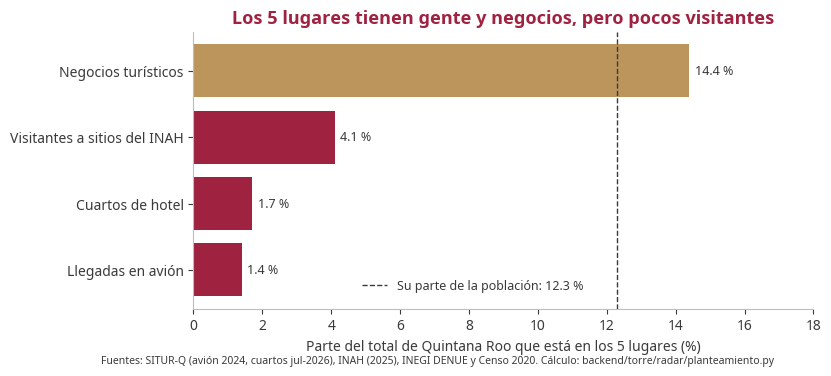

In [7]:
# Gráfica: parte de cada dimensión que tienen los 5 lugares, contra su parte de la población.
g = conc.set_index("dimension").cuota_5_lugares_pct.drop("Población").sort_values()
poblacion = conc.set_index("dimension").loc["Población", "cuota_5_lugares_pct"]
fig, ax = plt.subplots(figsize=(8, 3.6))
barras = ax.barh(g.index, g.values, color=[DORADO if v >= poblacion else GUINDA for v in g.values])
ax.axvline(poblacion, color=GRIS_TEXTO, ls="--", lw=1, label=f"Su parte de la población: {poblacion:.1f} %")
ax.legend(frameon=False, loc="lower center", bbox_to_anchor=(0.45, 0.02), fontsize=9)
ax.bar_label(barras, labels=[f"{v:.1f} %" for v in g.values], padding=4, fontsize=9)
ax.set_xlabel("Parte del total de Quintana Roo que está en los 5 lugares (%)")
ax.set_title("Los 5 lugares tienen gente y negocios, pero pocos visitantes")
ax.set_xlim(0, max(g.max(), poblacion) * 1.25)
fig.text(0.01, -0.04, "Fuentes: SITUR-Q (avión 2024, cuartos jul-2026), INAH (2025), INEGI DENUE y Censo 2020. "
         "Cálculo: backend/torre/radar/planteamiento.py", fontsize=7.5, color=GRIS_TEXTO)
destino = RAIZ / "docs" / "ejecutivo" / "figuras" / "f07_concentracion.png"
fig.savefig(destino)
plt.show()

**Qué dice la gráfica:**
- En los cinco lugares vive el **12.3 %** de la gente del estado y está el **14.4 %** de sus negocios turísticos.
- Pero ahí llega el **1.4 %** de los pasajeros aéreos, hay el **1.7 %** de los cuartos de hotel y va el **4.1 %** de los
  visitantes del INAH.
- Los negocios siguen a la población; los visitantes, no. Esa es la relación que la campaña quiere mover.
- **Cuidado al leerla:** muchos de esos negocios (sobre todo restaurantes de Chetumal) atienden también a los
  residentes; y la razón contra la población es una comparación, no una meta.

### 4.3 Una comprobación antes de sumar cuartos
SITUR-Q publica zonas (Riviera Maya, Grand Costa Maya) y destinos que están dentro de ellas ("miembros"). ¿Una zona es
la suma de sus miembros?

In [8]:
pl.comprobar_zonas()

,zona,cuartos_zona,suma_miembros,miembros,diferencia
0,Grand Costa Maya,4360.0,4315.0,"Chetumal, Bacalar, Mahahual",45.0
1,Riviera Maya,59632.0,22923.0,"Playa del Carmen, Tulum",36709.0


**No siempre.** Grand Costa Maya casi cuadra (45 cuartos de diferencia), pero Riviera Maya tiene 36,709 cuartos más
que Playa del Carmen y Tulum juntos: incluye lugares que SITUR-Q no publica por separado. Por eso el total estatal suma
**destinos + zonas** y no miembros; si se sumaran miembros, se perderían esos cuartos. "Caribe Mexicano" no dice qué
contiene y se deja fuera.

## 5. Qué se concluye y qué sigue
1. **El problema es analizable con datos:** hay 9 variables de presión y 3 de capacidad con serie medida, y los huecos
   están identificados (no se rellenan).
2. **La concentración es medible y alta:** el avión tiene $HHI^*=0.81$; en cuartos y visitantes del INAH una sola
   unidad tiene entre 42 % y 54 % del total.
3. **Los cinco lugares tienen gente y negocios, pero pocos visitantes.** Es la relación central del planteamiento y
   responde en parte a la pregunta secundaria 1 (patrones espaciales de concentración).
4. **Siguiente (Fase 4, Radar):** con las variables de presión y capacidad se construye el índice de presión
   turística. Antes, **Brandon decide** los pesos de cada variable y los cortes entre tranquilo, concurrido y saturado.